Using device: cpu
총 10개의 파일 발견. 통합 데이터 로드 시작...
데이터 스케일링 진행 중...
특성 선택 시작 (원본 특성 수: 79개)
-> 1단계 [분산 필터링(기준: < 0.01)]: 61개 남음
-> 2단계 [상관관계 필터링(기준: > 0.95)]: 32개 남음
신경망 입력 피처 축소 완료: 79개 -> 32개
로드 완료 -> 정상 데이터 수: 13484708, 공격 데이터 수: 2748294

========= DQN 기반 NIDS 학습 시작 =========
에피   1/800 | 보상:  -948.0 | 정확도:  50.8% | 오탐율(FPR):  50.2% | 미탐율(FNR):  48.2% | 공격비율:  50.0% | 입실론: 1.000
에피   5/800 | 보상: -1042.0 | 정확도:  49.1% | 오탐율(FPR):  50.6% | 미탐율(FNR):  51.2% | 공격비율:  50.0% | 입실론: 0.984
에피  10/800 | 보상:  -908.0 | 정확도:  51.8% | 오탐율(FPR):  49.2% | 미탐율(FNR):  47.2% | 공격비율:  50.0% | 입실론: 0.965
에피  15/800 | 보상:  -860.0 | 정확도:  52.8% | 오탐율(FPR):  48.6% | 미탐율(FNR):  45.8% | 공격비율:  50.0% | 입실론: 0.945
에피  20/800 | 보상:  -924.0 | 정확도:  53.0% | 오탐율(FPR):  44.8% | 미탐율(FNR):  49.2% | 공격비율:  50.0% | 입실론: 0.927
에피  25/800 | 보상:  -670.0 | 정확도:  57.3% | 오탐율(FPR):  44.6% | 미탐율(FNR):  40.8% | 공격비율:  50.0% | 입실론: 0.908
에피  30/800 | 보상:  -738.0 | 정확도:  54.9% | 오탐율(FPR):  48.4% | 미탐율(FNR):  41.8% | 공격비율:  50.0% |

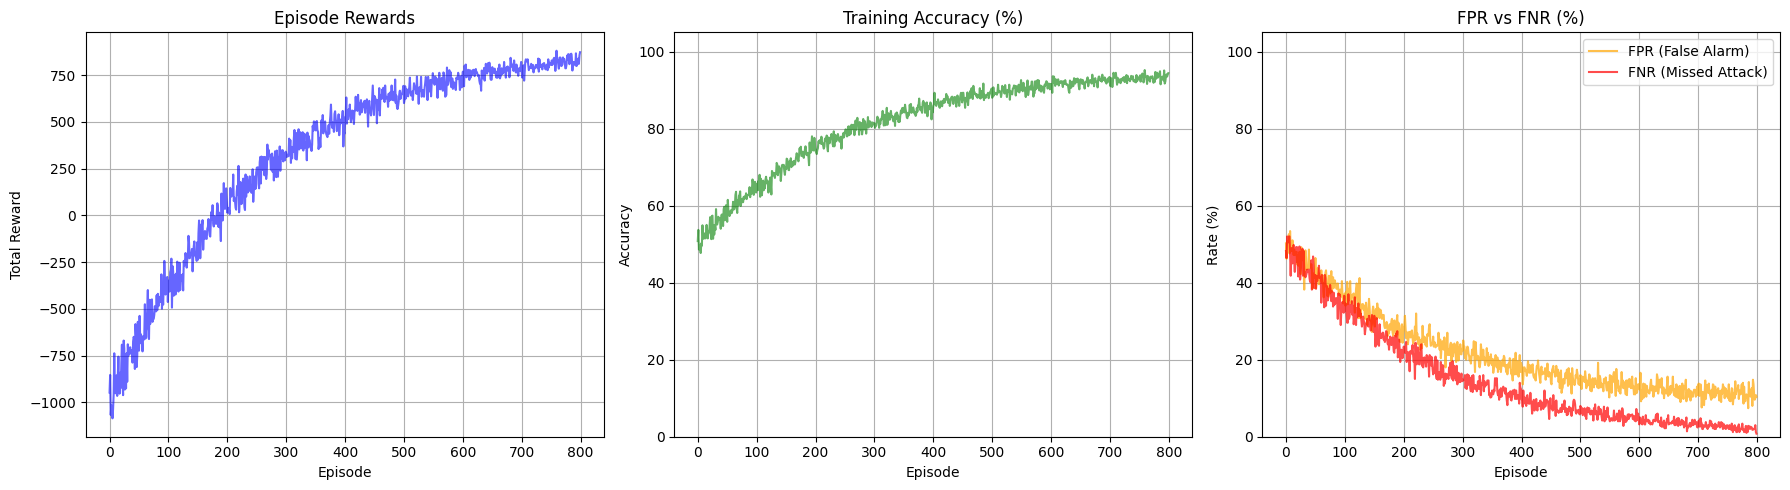

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold  # 분산 필터링용
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 강화학습 환경 (Feature Selection 적용)
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000):
        super(NIDSEnv, self).__init__()
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        print(f"총 {len(file_list)}개의 파일 발견. 통합 데이터 로드 시작...")
        
        X_list = []
        y_list = []
        
        for file in file_list:
            df = pd.read_csv(file, low_memory=False)
            X_sub = df.drop(columns=['Label', 'Timestamp'], errors='ignore')
            X_sub = X_sub.select_dtypes(include=[np.number]).astype(np.float32)
            y_sub = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
            
            X_list.append(X_sub)
            y_list.append(y_sub)
            
        self.X = pd.concat(X_list, ignore_index=True)
        self.y = np.concatenate(y_list, axis=0)
        del X_list, y_list
        
        # 데이터 정제 (Inf, NaN 처리)
        X_np = self.X.to_numpy(dtype=np.float32)
        X_np[np.isinf(X_np)] = np.nan
        col_means = np.nanmean(X_np, axis=0)
        col_means = np.nan_to_num(col_means, nan=0.0)
        
        inds = np.where(np.isnan(X_np))
        X_np[inds] = np.take(col_means, inds[1])
        
        np.clip(X_np, a_min=0, a_max=None, out=X_np)
        X_log = np.log1p(X_np)
        del X_np
        
        print("데이터 스케일링 진행 중...")
        scaler = MinMaxScaler()
        X_scaled_full = scaler.fit_transform(X_log)
        del X_log
        
        # -------------------------------------------------------------
        # [Feature Selection - Filter Method 적용]
        # -------------------------------------------------------------
        orig_feature_count = X_scaled_full.shape[1]
        print(f"특성 선택 시작 (원본 특성 수: {orig_feature_count}개)")
        
        # 1) 분산 기준 필터링 (Variance Threshold)
        # 분산이 0.01 미만 = 데이터의 99% 이상이 동일한 값을 가지는 노이즈 컬럼 제거
        var_thresh = 0.01
        selector = VarianceThreshold(threshold=var_thresh)
        X_var_filtered = selector.fit_transform(X_scaled_full)
        
        # 남은 특성들의 인덱스를 추적하기 위해 DataFrame 변환
        remaining_indices = selector.get_support(indices=True)
        df_filtered = pd.DataFrame(X_var_filtered, columns=remaining_indices)
        print(f"-> 1단계 [분산 필터링(기준: < {var_thresh})]: {df_filtered.shape[1]}개 남음")
        
        # 2) 상관관계 기반 필터링 (Correlation Filtering)
        # 상관계수가 0.95를 초과하는 피처 쌍 중 하나를 제거
        corr_thresh = 0.95
        corr_matrix = df_filtered.corr().abs()
        
        # 상삼각 행렬(Upper triangle)을 구하여 중복 연산 방지
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        # 임계값을 넘는 피처(열) 이름(여기서는 원본 인덱스 번호) 수집
        to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > corr_thresh)]
        
        # 최종 데이터셋 결정
        self.X_scaled = df_filtered.drop(columns=to_drop).to_numpy(dtype=np.float32)
        print(f"-> 2단계 [상관관계 필터링(기준: > {corr_thresh})]: {self.X_scaled.shape[1]}개 남음")
        print(f"신경망 입력 피처 축소 완료: {orig_feature_count}개 -> {self.X_scaled.shape[1]}개")
        # -------------------------------------------------------------
        
        self.total_rows = len(self.y)
        self.max_steps = max_steps
        self.current_step = 0
        
        self.benign_indices = np.where(self.y == 0)[0]
        self.attack_indices = np.where(self.y == 1)[0]
        
        print(f"로드 완료 -> 정상 데이터 수: {len(self.benign_indices)}, 공격 데이터 수: {len(self.attack_indices)}")
        if len(self.attack_indices) == 0:
            raise ValueError("데이터셋 내에 공격(Attack) 데이터가 존재하지 않습니다. 파일을 확인해주세요.")
        
        self.episode_indices = []
        
        num_features = self.X_scaled.shape[1]
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(num_features,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        
        half_steps = self.max_steps // 2
        sampled_benign = np.random.choice(self.benign_indices, half_steps, replace=True)
        sampled_attack = np.random.choice(self.attack_indices, half_steps, replace=True)
        
        self.episode_indices = np.concatenate([sampled_benign, sampled_attack])
        np.random.shuffle(self.episode_indices)
        
        state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        info = {}
        return state, info

    def step(self, action):
        actual_label = self.y[self.episode_indices[self.current_step]]
        
        if action == actual_label:
            reward = 1.0  
        else:
            if actual_label == 1 and action == 0:
                reward = -5.0  # 미탐 패널티
            else:
                reward = -1.0  # 오탐 패널티
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info

# ==========================================
# 2. DQN 아키텍처
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 에이전트
# ==========================================
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00025)
        self.memory = deque(maxlen=60000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        
        self.epsilon_decay = 0.996 
        self.epsilon_min = 0.01
        
        self.batch_size = 64
        self.tau = 0.005 
        self.focal_gamma = 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).to(device)
                q_values = self.policy_net(state_t)
                return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return
        
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        
        p_t = torch.exp(-td_error)
        focal_weight = (1 - p_t) ** self.focal_gamma
        
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# ==========================================
# 4. 메인 루프 실행
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    env = NIDSEnv(folder_path=folder_path, max_steps=1000)
    agent = DQNAgent(state_dim=env.observation_space.shape[0], action_dim=env.action_space.n)
    
    num_episodes = 800 
    
    history_rewards = []
    history_accuracy = []
    history_fpr = []
    history_fnr = []
    
    print("\n========= DQN 기반 NIDS 학습 시작 =========")
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward, next_state, done)
            agent.train_step()
            
            episode_reward += reward
            state = next_state
            
            act = info["actual"]
            pred = info["predicted"]
            
            if act == 1 and pred == 1: tp += 1
            elif act == 0 and pred == 0: tn += 1
            elif act == 0 and pred == 1: fp += 1
            elif act == 1 and pred == 0: fn += 1
                
            if done:
                break
                
        accuracy = ((tp + tn) / env.max_steps) * 100
        fpr = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0.0
        fnr = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0.0
        attack_ratio = ((tp + fn) / env.max_steps) * 100
        
        history_rewards.append(episode_reward)
        history_accuracy.append(accuracy)
        history_fpr.append(fpr)
        history_fnr.append(fnr)
        
        if (episode + 1) % 5 == 0 or episode == 0:
            print(f"에피 {episode+1:3d}/{num_episodes} | "
                  f"보상: {episode_reward:7.1f} | "
                  f"정확도: {accuracy:5.1f}% | "
                  f"오탐율(FPR): {fpr:5.1f}% | "
                  f"미탐율(FNR): {fnr:5.1f}% | "
                  f"공격비율: {attack_ratio:5.1f}% | "
                  f"입실론: {agent.epsilon:.3f}")
        
        agent.decay_epsilon()
            
    print("========= 학습 완료 =========")
    
    # ==========================================
    # 5. 결과 시각화 그래프 출력
    # ==========================================
    plt.figure(figsize=(18, 5))

    # 누적 보상 그래프
    plt.subplot(1, 3, 1)
    plt.plot(history_rewards, color='blue', alpha=0.6)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)

    # 정확도 그래프
    plt.subplot(1, 3, 2)
    plt.plot(history_accuracy, color='green', alpha=0.6)
    plt.title('Training Accuracy (%)')
    plt.xlabel('Episode')
    plt.ylabel('Accuracy')
    plt.ylim(0, 105)
    plt.grid(True)

    # 오탐율 & 미탐율 비교 그래프
    plt.subplot(1, 3, 3)
    plt.plot(history_fpr, label='FPR (False Alarm)', color='orange', alpha=0.7)
    plt.plot(history_fnr, label='FNR (Missed Attack)', color='red', alpha=0.7)
    plt.title('FPR vs FNR (%)')
    plt.xlabel('Episode')
    plt.ylabel('Rate (%)')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Using device: cpu
총 10개의 파일 발견. 데이터 로드 및 병합 시작...
데이터 스케일링 진행 중...
데이터 전처리 완료. 가용한 총 원본 특성 수: 79개
트리 모델(ExtraTrees)을 통해 정밀 특성 중요도 계산 중...
[환경 설정 변경] 상위 20개의 특성을 사용합니다. (입력 차원: 20)

실험 계획: 후보군 [10, 20, 30, 40, 50, 60, 70, 79]에 대해 각각 100 에피소드씩 테스트를 진행합니다.

 실험 시작 -> 특성 개수(N): 10개
[환경 설정 변경] 상위 10개의 특성을 사용합니다. (입력 차원: 10)
  [N=10] 에피  20/100 | 보상:  -796.0 | 정확도:  54.2%
  [N=10] 에피  40/100 | 보상:  -584.0 | 정확도:  60.2%
  [N=10] 에피  60/100 | 보상:  -506.0 | 정확도:  61.3%
  [N=10] 에피  80/100 | 보상:  -478.0 | 정확도:  63.5%
  [N=10] 에피 100/100 | 보상:  -384.0 | 정확도:  65.0%

 실험 시작 -> 특성 개수(N): 20개
[환경 설정 변경] 상위 20개의 특성을 사용합니다. (입력 차원: 20)
  [N=20] 에피  20/100 | 보상:  -924.0 | 정확도:  52.8%
  [N=20] 에피  40/100 | 보상:  -812.0 | 정확도:  54.2%
  [N=20] 에피  60/100 | 보상:  -546.0 | 정확도:  61.3%
  [N=20] 에피  80/100 | 보상:  -452.0 | 정확도:  62.2%
  [N=20] 에피 100/100 | 보상:  -334.0 | 정확도:  65.9%

 실험 시작 -> 특성 개수(N): 30개
[환경 설정 변경] 상위 30개의 특성을 사용합니다. (입력 차원: 30)
  [N=30] 에피  20/100 | 보상:  -830.0 | 정확도:  54.7%
  [N=30] 에피  40/1

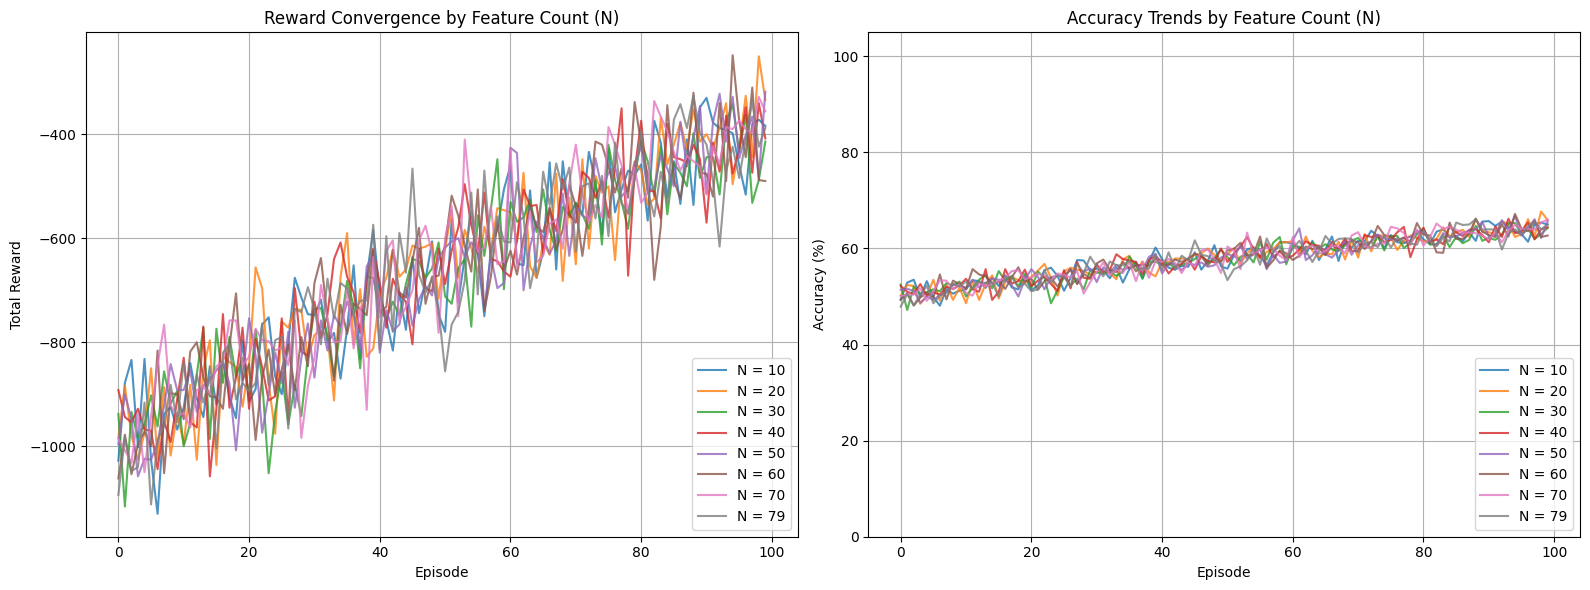

In [4]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 강화학습 환경 (동적 Feature Selection 지원)
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000):
        super(NIDSEnv, self).__init__()
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        print(f"총 {len(file_list)}개의 파일 발견. 데이터 로드 및 병합 시작...")
        
        X_list, y_list = [], []
        for file in file_list:
            df = pd.read_csv(file, low_memory=False)
            X_sub = df.drop(columns=['Label', 'Timestamp'], errors='ignore')
            X_sub = X_sub.select_dtypes(include=[np.number]).astype(np.float32)
            y_sub = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
            X_list.append(X_sub)
            y_list.append(y_sub)
            
        self.X = pd.concat(X_list, ignore_index=True)
        self.y = np.concatenate(y_list, axis=0)
        del X_list, y_list
        
        # 데이터 정제 (Inf, NaN 처리)
        X_np = self.X.to_numpy(dtype=np.float32)
        X_np[np.isinf(X_np)] = np.nan
        col_means = np.nanmean(X_np, axis=0)
        col_means = np.nan_to_num(col_means, nan=0.0)
        inds = np.where(np.isnan(X_np))
        X_np[inds] = np.take(col_means, inds[1])
        
        np.clip(X_np, a_min=0, a_max=None, out=X_np)
        X_log = np.log1p(X_np)
        del X_np
        
        print("데이터 스케일링 진행 중...")
        scaler = MinMaxScaler()
        self.X_scaled_full = scaler.fit_transform(X_log)
        del X_log
        
        # 실제 데이터셋의 원본 특성 최대 개수 저장
        self.max_available_features = self.X_scaled_full.shape[1]
        print(f"데이터 전처리 완료. 가용한 총 원본 특성 수: {self.max_available_features}개")
        
        # -------------------------------------------------------------
        # [트리 모델을 통한 정밀 특성 중요도 계산]
        # -------------------------------------------------------------
        print("트리 모델(ExtraTrees)을 통해 정밀 특성 중요도 계산 중...")
        sample_size = min(100000, len(self.y))
        sample_indices = np.random.choice(len(self.y), sample_size, replace=False)
        
        tree_model = ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        tree_model.fit(self.X_scaled_full[sample_indices], self.y[sample_indices])
        
        # 중요도가 높은 순서대로 인덱스 정렬 보관
        self.sorted_feature_indices = np.argsort(tree_model.feature_importances_)[::-1]
        # -------------------------------------------------------------
        
        self.total_rows = len(self.y)
        self.max_steps = max_steps
        self.current_step = 0
        
        self.benign_indices = np.where(self.y == 0)[0]
        self.attack_indices = np.where(self.y == 1)[0]
        
        self.action_space = spaces.Discrete(2)
        
        # 기본값으로 상위 20개 특성 설정
        self.set_top_k_features(k=20)

    def set_top_k_features(self, k):
        """특성 개수 N을 외부에서 동적으로 변경하고 차원을 재조정하는 함수"""
        # 안전장치: 요청한 k가 사용 가능한 최대 특성 수보다 크면 최대치로 강제 제한
        if k > self.max_available_features:
            k = self.max_available_features
            
        self.selected_indices = self.sorted_feature_indices[:k]
        self.X_scaled = self.X_scaled_full[:, self.selected_indices]
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(k,), dtype=np.float32)
        print(f"[환경 설정 변경] 상위 {k}개의 특성을 사용합니다. (입력 차원: {k})")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        half_steps = self.max_steps // 2
        sampled_benign = np.random.choice(self.benign_indices, half_steps, replace=True)
        sampled_attack = np.random.choice(self.attack_indices, half_steps, replace=True)
        
        self.episode_indices = np.concatenate([sampled_benign, sampled_attack])
        np.random.shuffle(self.episode_indices)
        
        state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        return state, {}

    def step(self, action):
        actual_label = self.y[self.episode_indices[self.current_step]]
        if action == actual_label:
            reward = 1.0  
        else:
            reward = -5.0 if (actual_label == 1 and action == 0) else -1.0
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info


# ==========================================
# 2. DQN 아키텍처 및 3. 에이전트
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x): return self.network(x)


class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00025)
        self.memory = deque(maxlen=60000)
        self.gamma, self.epsilon, self.epsilon_decay, self.epsilon_min = 0.99, 1.0, 0.996, 0.01
        self.batch_size, self.tau, self.focal_gamma = 64, 0.005, 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).to(device)
            return torch.argmax(self.policy_net(state_t)).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size: return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        focal_weight = (1 - torch.exp(-td_error)) ** self.focal_gamma
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# ==========================================
# 4. 메인 루프 (10 단위 연속 정밀 실험 실행)
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    env = NIDSEnv(folder_path=folder_path, max_steps=1000)
    
    # [수정 지점] 가용한 최대 특성 개수 이하의 후보군만 유연하게 생성 및 중복 제거
    raw_candidates = list(range(10, 81, 10))
    feature_counts_to_test = []
    
    for cand in raw_candidates:
        if cand <= env.max_available_features:
            feature_counts_to_test.append(cand)
        else:
            # 마지막으로 데이터셋이 가질 수 있는 최댓값을 후보군에 추가하고 종료
            feature_counts_to_test.append(env.max_available_features)
            break
            
    # 혹시 최댓값이 딱 떨어져서 중복되는 것을 방지하기 위해 유니크 처리 정렬
    feature_counts_to_test = sorted(list(set(feature_counts_to_test)))
    
    results = {}
    episodes_per_test = 100 
    
    print(f"\n실험 계획: 후보군 {feature_counts_to_test}에 대해 각각 {episodes_per_test} 에피소드씩 테스트를 진행합니다.")
    
    for k in feature_counts_to_test:
        print(f"\n=========================================")
        print(f" 실험 시작 -> 특성 개수(N): {k}개")
        print(f"=========================================")
        
        env.set_top_k_features(k)
        
        # 환경에서 가용하도록 제한된 실제 특성 수(env.observation_space.shape[0])를 사용하여 차원 일치 보장
        actual_k = env.observation_space.shape[0]
        agent = DQNAgent(state_dim=actual_k, action_dim=env.action_space.n)
        
        history_rewards = []
        history_accuracy = []
        
        for episode in range(episodes_per_test):
            state, info = env.reset()
            episode_reward = 0
            tp, tn, fp, fn = 0, 0, 0, 0
            
            for step in range(env.max_steps):
                action = agent.select_action(state)
                next_state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                
                agent.store_transition(state, action, reward, next_state, done)
                agent.train_step()
                
                episode_reward += reward
                state = next_state
                
                act, pred = info["actual"], info["predicted"]
                if act == 1 and pred == 1: tp += 1
                elif act == 0 and pred == 0: tn += 1
                elif act == 0 and pred == 1: fp += 1
                elif act == 1 and pred == 0: fn += 1
                if done: break
                    
            accuracy = ((tp + tn) / env.max_steps) * 100
            history_rewards.append(episode_reward)
            history_accuracy.append(accuracy)
            
            if (episode + 1) % 20 == 0:
                print(f"  [N={actual_k:2d}] 에피 {episode+1:3d}/{episodes_per_test} | 보상: {episode_reward:7.1f} | 정확도: {accuracy:5.1f}%")
            
            agent.decay_epsilon()
            
        results[actual_k] = {
            "rewards": history_rewards,
            "accuracy": history_accuracy
        }
        
    print("\n========= 모든 후보군 실험 완료 =========")

    # ==========================================
    # 5. 결과 시각화 및 비교 그래프 출력
    # ==========================================
    plt.figure(figsize=(16, 6))

    # 1) 각 N별 누적 보상 추이 비교
    plt.subplot(1, 2, 1)
    for k, data in results.items():
        plt.plot(data["rewards"], label=f"N = {k}", alpha=0.8)
    plt.title("Reward Convergence by Feature Count (N)")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2) 각 N별 정확도 추이 비교
    plt.subplot(1, 2, 2)
    for k, data in results.items():
        plt.plot(data["accuracy"], label=f"N = {k}", alpha=0.8)
    plt.title("Accuracy Trends by Feature Count (N)")
    plt.xlabel("Episode")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 105)
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Using device: cpu
총 10개의 파일 발견. 데이터 로드 및 병합 시작...
데이터 스케일링 진행 중...
최종 특성 개수(20개) 기반 핵심 특성 추출 중...
-> 최종 신경망 입력 피처 결정 완료: 20개

========= N=20 메인 본 학습 시작 (총 800 에피소드) =========
에피   1/800 | 보상:  -826.0 | 정확도:  53.5% | 오탐율(FPR):  48.2% | 미탐율(FNR):  44.8% | 입실론: 1.000
에피  10/800 | 보상:  -910.0 | 정확도:  51.9% | 오탐율(FPR):  48.8% | 미탐율(FNR):  47.4% | 입실론: 0.965
에피  20/800 | 보상:  -886.0 | 정확도:  52.3% | 오탐율(FPR):  48.8% | 미탐율(FNR):  46.6% | 입실론: 0.927
에피  30/800 | 보상:  -806.0 | 정확도:  54.5% | 오탐율(FPR):  46.2% | 미탐율(FNR):  44.8% | 입실론: 0.890
에피  40/800 | 보상:  -750.0 | 정확도:  55.3% | 오탐율(FPR):  46.6% | 미탐율(FNR):  42.8% | 입실론: 0.855
에피  50/800 | 보상:  -762.0 | 정확도:  54.9% | 오탐율(FPR):  47.2% | 미탐율(FNR):  43.0% | 입실론: 0.822
에피  60/800 | 보상:  -558.0 | 정확도:  60.3% | 오탐율(FPR):  41.2% | 미탐율(FNR):  38.2% | 입실론: 0.789
에피  70/800 | 보상:  -568.0 | 정확도:  60.2% | 오탐율(FPR):  41.0% | 미탐율(FNR):  38.6% | 입실론: 0.758
에피  80/800 | 보상:  -552.0 | 정확도:  61.0% | 오탐율(FPR):  39.4% | 미탐율(FNR):  38.6% | 입실론: 0.729
에피  90/800 | 보상

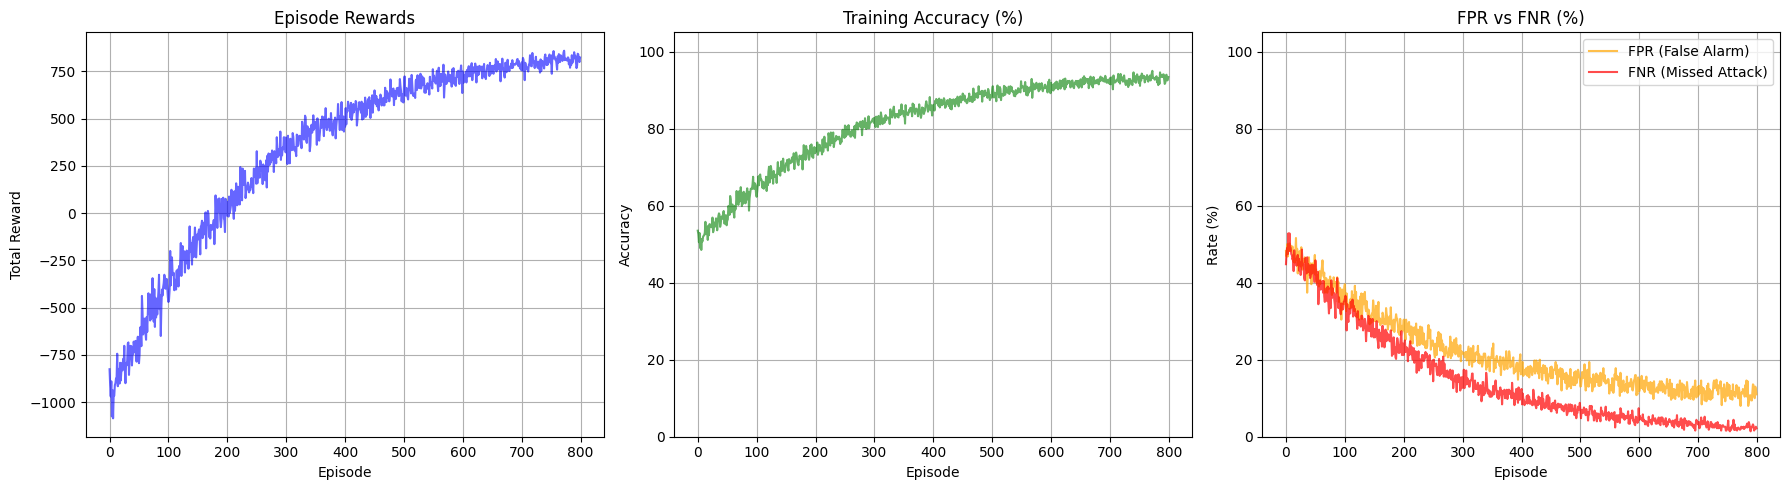

In [5]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 강화학습 환경
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000, final_n_features=20):
        super(NIDSEnv, self).__init__()
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        print(f"총 {len(file_list)}개의 파일 발견. 데이터 로드 및 병합 시작...")
        
        X_list, y_list = [], []
        for file in file_list:
            df = pd.read_csv(file, low_memory=False)
            X_sub = df.drop(columns=['Label', 'Timestamp'], errors='ignore')
            X_sub = X_sub.select_dtypes(include=[np.number]).astype(np.float32)
            y_sub = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
            X_list.append(X_sub)
            y_list.append(y_sub)
            
        self.X = pd.concat(X_list, ignore_index=True)
        self.y = np.concatenate(y_list, axis=0)
        del X_list, y_list
        
        X_np = self.X.to_numpy(dtype=np.float32)
        X_np[np.isinf(X_np)] = np.nan
        col_means = np.nanmean(X_np, axis=0)
        col_means = np.nan_to_num(col_means, nan=0.0)
        inds = np.where(np.isnan(X_np))
        X_np[inds] = np.take(col_means, inds[1])
        
        np.clip(X_np, a_min=0, a_max=None, out=X_np)
        X_log = np.log1p(X_np)
        del X_np
        
        print("데이터 스케일링 진행 중...")
        scaler = MinMaxScaler()
        X_scaled_full = scaler.fit_transform(X_log)
        del X_log
        
        # -------------------------------------------------------------
        # [선택된 최종 N개 특성 추출 고정]
        # -------------------------------------------------------------
        print(f"최종 특성 개수({final_n_features}개) 기반 핵심 특성 추출 중...")
        sample_size = min(100000, len(self.y))
        sample_indices = np.random.choice(len(self.y), sample_size, replace=False)
        
        tree_model = ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        tree_model.fit(X_scaled_full[sample_indices], self.y[sample_indices])
        
        sorted_indices = np.argsort(tree_model.feature_importances_)[::-1]
        self.selected_indices = sorted_indices[:final_n_features]
        
        # 데이터 셋 최종 확정
        self.X_scaled = X_scaled_full[:, self.selected_indices]
        print(f"-> 최종 신경망 입력 피처 결정 완료: {self.X_scaled.shape[1]}개")
        # -------------------------------------------------------------
        
        self.total_rows = len(self.y)
        self.max_steps = max_steps
        self.current_step = 0
        
        self.benign_indices = np.where(self.y == 0)[0]
        self.attack_indices = np.where(self.y == 1)[0]
        
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(final_n_features,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        half_steps = self.max_steps // 2
        sampled_benign = np.random.choice(self.benign_indices, half_steps, replace=True)
        sampled_attack = np.random.choice(self.attack_indices, half_steps, replace=True)
        
        self.episode_indices = np.concatenate([sampled_benign, sampled_attack])
        np.random.shuffle(self.episode_indices)
        
        state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        return state, {}

    def step(self, action):
        actual_label = self.y[self.episode_indices[self.current_step]]
        if action == actual_label:
            reward = 1.0  
        else:
            reward = -5.0 if (actual_label == 1 and action == 0) else -1.0
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info

# ==========================================
# 2. DQN 아키텍처 및 3. 에이전트
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x): return self.network(x)

class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00025)
        self.memory = deque(maxlen=60000)
        self.gamma, self.epsilon, self.epsilon_decay, self.epsilon_min = 0.99, 1.0, 0.996, 0.01
        self.batch_size, self.tau, self.focal_gamma = 64, 0.005, 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).to(device)
            return torch.argmax(self.policy_net(state_t)).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size: return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        focal_weight = (1 - torch.exp(-td_error)) ** self.focal_gamma
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# ==========================================
# 4. 메인 본 학습 실행 루프
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    # 추천 스펙: 최적 특성 수 20개 고정, 스텝 수 1000 고정
    TARGET_FEATURES = 20
    env = NIDSEnv(folder_path=folder_path, max_steps=1000, final_n_features=TARGET_FEATURES)
    agent = DQNAgent(state_dim=TARGET_FEATURES, action_dim=env.action_space.n)
    
    # 수렴 안정화를 위한 800 에피소드 본 대결 시작
    num_episodes = 800 
    
    history_rewards = []
    history_accuracy = []
    history_fpr = []
    history_fnr = []
    
    print(f"\n========= N={TARGET_FEATURES} 메인 본 학습 시작 (총 {num_episodes} 에피소드) =========")
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward, next_state, done)
            agent.train_step()
            
            episode_reward += reward
            state = next_state
            
            act, pred = info["actual"], info["predicted"]
            if act == 1 and pred == 1: tp += 1
            elif act == 0 and pred == 0: tn += 1
            elif act == 0 and pred == 1: fp += 1
            elif act == 1 and pred == 0: fn += 1
            if done: break
                
        accuracy = ((tp + tn) / env.max_steps) * 100
        fpr = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0.0
        fnr = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0.0
        attack_ratio = ((tp + fn) / env.max_steps) * 100
        
        history_rewards.append(episode_reward)
        history_accuracy.append(accuracy)
        history_fpr.append(fpr)
        history_fnr.append(fnr)
        
        if (episode + 1) % 10 == 0 or episode == 0:
            print(f"에피 {episode+1:3d}/{num_episodes} | "
                  f"보상: {episode_reward:7.1f} | "
                  f"정확도: {accuracy:5.1f}% | "
                  f"오탐율(FPR): {fpr:5.1f}% | "
                  f"미탐율(FNR): {fnr:5.1f}% | "
                  f"입실론: {agent.epsilon:.3f}")
        
        agent.decay_epsilon()
            
    print("========= 메인 본 학습 완료 =========")
    
    # ==========================================
    # 5. 최종 결과 시각화 그래프 출력
    # ==========================================
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history_rewards, color='blue', alpha=0.6)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history_accuracy, color='green', alpha=0.6)
    plt.title('Training Accuracy (%)')
    plt.xlabel('Episode')
    plt.ylabel('Accuracy')
    plt.ylim(0, 105)
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history_fpr, label='FPR (False Alarm)', color='orange', alpha=0.7)
    plt.plot(history_fnr, label='FNR (Missed Attack)', color='red', alpha=0.7)
    plt.title('FPR vs FNR (%)')
    plt.xlabel('Episode')
    plt.ylabel('Rate (%)')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Using device: cpu
총 10개의 파일 발견. 데이터 로드 및 병합 시작...
데이터 스케일링 진행 중...
RFECV(교차검증 기반 재귀적 특성 제거) 분석 시작 (원본 피처: 79개)
AI가 데이터를 분석하여 최적의 특성 개수를 스스로 탐색합니다...
-> [결과] AI가 찾아낸 최적의 특성 개수: 9개
-> 최종 신경망 입력 피처 결정 완료: 79개 -> 9개

========= RFECV 메인 본 학습 시작 (총 800 에피소드) =========
에피   1/800 | 보상: -1020.0 | 정확도:  50.6% | 오탐율(FPR):  47.2% | 미탐율(FNR):  51.6% | 입실론: 1.000
에피  10/800 | 보상:  -998.0 | 정확도:  50.7% | 오탐율(FPR):  48.0% | 미탐율(FNR):  50.6% | 입실론: 0.965
에피  20/800 | 보상:  -952.0 | 정확도:  51.2% | 오탐율(FPR):  48.8% | 미탐율(FNR):  48.8% | 입실론: 0.927
에피  30/800 | 보상:  -768.0 | 정확도:  55.2% | 오탐율(FPR):  46.0% | 미탐율(FNR):  43.6% | 입실론: 0.890
에피  40/800 | 보상:  -724.0 | 정확도:  56.0% | 오탐율(FPR):  45.8% | 미탐율(FNR):  42.2% | 입실론: 0.855
에피  50/800 | 보상:  -686.0 | 정확도:  57.1% | 오탐율(FPR):  44.4% | 미탐율(FNR):  41.4% | 입실론: 0.822
에피  60/800 | 보상:  -628.0 | 정확도:  59.6% | 오탐율(FPR):  39.8% | 미탐율(FNR):  41.0% | 입실론: 0.789
에피  70/800 | 보상:  -596.0 | 정확도:  59.8% | 오탐율(FPR):  40.8% | 미탐율(FNR):  39.6% | 입실론: 0.758
에피  80/800 | 보상: 

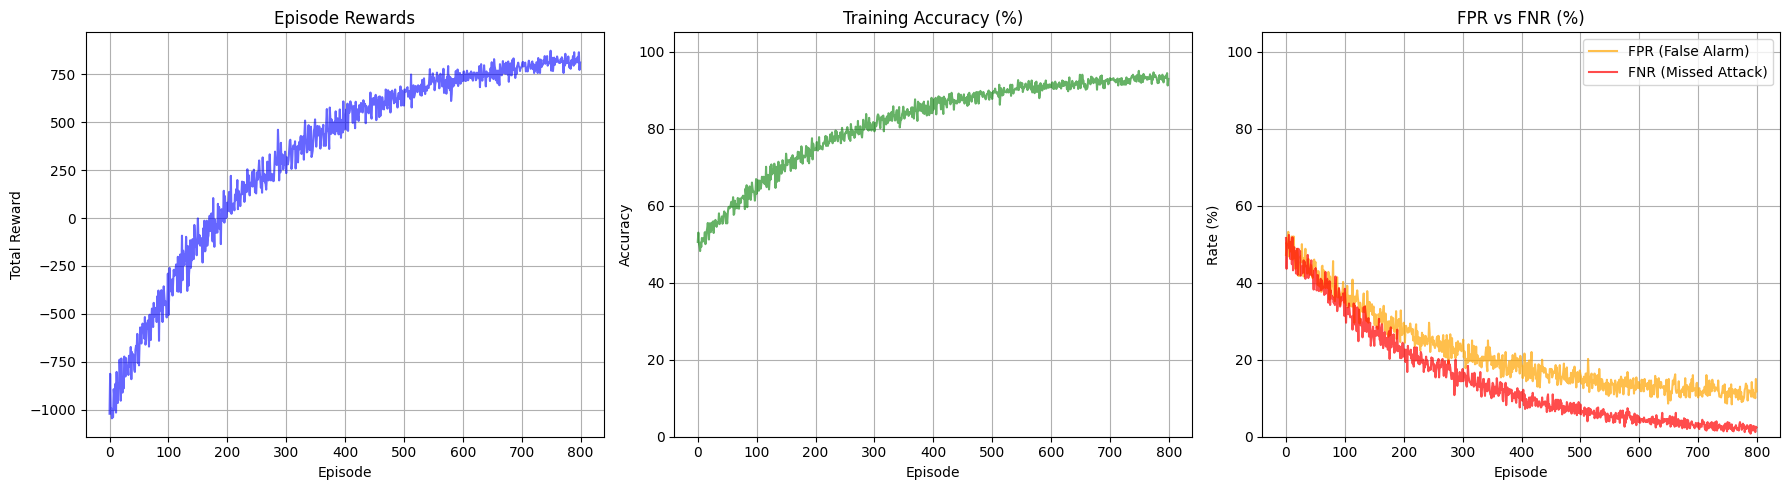

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV  # 자동으로 최적 개수를 찾는 RFECV 도입
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 강화학습 환경 (RFECV 특성 자동 최적화)
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000):
        super(NIDSEnv, self).__init__()
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        print(f"총 {len(file_list)}개의 파일 발견. 데이터 로드 및 병합 시작...")
        
        X_list, y_list = [], []
        for file in file_list:
            df = pd.read_csv(file, low_memory=False)
            X_sub = df.drop(columns=['Label', 'Timestamp'], errors='ignore')
            X_sub = X_sub.select_dtypes(include=[np.number]).astype(np.float32)
            y_sub = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
            X_list.append(X_sub)
            y_list.append(y_sub)
            
        self.X = pd.concat(X_list, ignore_index=True)
        self.y = np.concatenate(y_list, axis=0)
        del X_list, y_list
        
        # 데이터 정제 (Inf, NaN 처리)
        X_np = self.X.to_numpy(dtype=np.float32)
        X_np[np.isinf(X_np)] = np.nan
        col_means = np.nanmean(X_np, axis=0)
        col_means = np.nan_to_num(col_means, nan=0.0)
        inds = np.where(np.isnan(X_np))
        X_np[inds] = np.take(col_means, inds[1])
        
        np.clip(X_np, a_min=0, a_max=None, out=X_np)
        X_log = np.log1p(X_np)
        del X_np
        
        print("데이터 스케일링 진행 중...")
        scaler = MinMaxScaler()
        X_scaled_full = scaler.fit_transform(X_log)
        del X_log
        
        # -------------------------------------------------------------
        # [RFECV 기반 특성 개수 및 조합 완전 자동 최적화]
        # -------------------------------------------------------------
        orig_feature_count = X_scaled_full.shape[1]
        print(f"RFECV(교차검증 기반 재귀적 특성 제거) 분석 시작 (원본 피처: {orig_feature_count}개)")
        print("AI가 데이터를 분석하여 최적의 특성 개수를 스스로 탐색합니다...")
        
        # 교차 검증은 연산량이 많으므로 신뢰도를 유지하는 선에서 샘플 수 조절(30,000개)
        sample_size = min(30000, len(self.y))
        sample_indices = np.random.choice(len(self.y), sample_size, replace=False)
        
        base_estimator = ExtraTreesClassifier(n_estimators=30, random_state=42, n_jobs=-1)
        
        # step=5: 하위 특성을 5개씩 쳐내며 속도 향상, cv=3: 3-Fold 교차검증으로 성능 검증
        rfecv = RFECV(estimator=base_estimator, step=5, cv=3, scoring='accuracy', n_jobs=-1)
        rfecv.fit(X_scaled_full[sample_indices], self.y[sample_indices])
        
        # RFECV가 스스로 선택한 최적의 특성 수와 데이터 마스킹 적용
        self.final_n_features = rfecv.n_features_
        self.X_scaled = X_scaled_full[:, rfecv.support_]
        
        print(f"-> [결과] AI가 찾아낸 최적의 특성 개수: {self.final_n_features}개")
        print(f"-> 최종 신경망 입력 피처 결정 완료: {orig_feature_count}개 -> {self.X_scaled.shape[1]}개")
        # -------------------------------------------------------------
        
        self.total_rows = len(self.y)
        self.max_steps = max_steps
        self.current_step = 0
        
        self.benign_indices = np.where(self.y == 0)[0]
        self.attack_indices = np.where(self.y == 1)[0]
        
        # 발견된 최종 특성 수(self.final_n_features)로 관측 공간 자동 리사이징
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(self.final_n_features,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        half_steps = self.max_steps // 2
        sampled_benign = np.random.choice(self.benign_indices, half_steps, replace=True)
        sampled_attack = np.random.choice(self.attack_indices, half_steps, replace=True)
        
        self.episode_indices = np.concatenate([sampled_benign, sampled_attack])
        np.random.shuffle(self.episode_indices)
        
        state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        return state, {}

    def step(self, action):
        actual_label = self.y[self.episode_indices[self.current_step]]
        if action == actual_label:
            reward = 1.0  
        else:
            reward = -5.0 if (actual_label == 1 and action == 0) else -1.0
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info


# ==========================================
# 2. DQN 아키텍처 및 3. 에이전트
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x): return self.network(x)


class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00025)
        self.memory = deque(maxlen=60000)
        self.gamma, self.epsilon, self.epsilon_decay, self.epsilon_min = 0.99, 1.0, 0.996, 0.01
        self.batch_size, self.tau, self.focal_gamma = 64, 0.005, 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).to(device)
            return torch.argmax(self.policy_net(state_t)).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size: return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        focal_weight = (1 - torch.exp(-td_error)) ** self.focal_gamma
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# ==========================================
# 4. 메인 본 학습 실행 루프
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    # 뼈대 환경 생성 (max_steps는 원래 스펙인 1000 고정)
    env = NIDSEnv(folder_path=folder_path, max_steps=1000)
    
    # 에이전트는 RFECV가 스스로 도출해낸 차원(env.final_n_features)을 전달받아 유연하게 생성됩니다.
    agent = DQNAgent(state_dim=env.final_n_features, action_dim=env.action_space.n)
    
    # 장기 수렴용 800 에피소드 본 대결 시작
    num_episodes = 800 
    
    history_rewards = []
    history_accuracy = []
    history_fpr = []
    history_fnr = []
    
    print(f"\n========= RFECV 메인 본 학습 시작 (총 {num_episodes} 에피소드) =========")
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward, next_state, done)
            agent.train_step()
            
            episode_reward += reward
            state = next_state
            
            act, pred = info["actual"], info["predicted"]
            if act == 1 and pred == 1: tp += 1
            elif act == 0 and pred == 0: tn += 1
            elif act == 0 and pred == 1: fp += 1
            elif act == 1 and pred == 0: fn += 1
            if done: break
                
        accuracy = ((tp + tn) / env.max_steps) * 100
        fpr = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0.0
        fnr = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0.0
        
        history_rewards.append(episode_reward)
        history_accuracy.append(accuracy)
        history_fpr.append(fpr)
        history_fnr.append(fnr)
        
        if (episode + 1) % 10 == 0 or episode == 0:
            print(f"에피 {episode+1:3d}/{num_episodes} | "
                  f"보상: {episode_reward:7.1f} | "
                  f"정확도: {accuracy:5.1f}% | "
                  f"오탐율(FPR): {fpr:5.1f}% | "
                  f"미탐율(FNR): {fnr:5.1f}% | "
                  f"입실론: {agent.epsilon:.3f}")
        
        agent.decay_epsilon()
            
    print("========= 메인 본 학습 완료 =========")
    
    # ==========================================
    # 5. 최종 결과 시각화 그래프 출력
    # ==========================================
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history_rewards, color='blue', alpha=0.6)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history_accuracy, color='green', alpha=0.6)
    plt.title('Training Accuracy (%)')
    plt.xlabel('Episode')
    plt.ylabel('Accuracy')
    plt.ylim(0, 105)
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history_fpr, label='FPR (False Alarm)', color='orange', alpha=0.7)
    plt.plot(history_fnr, label='FNR (Missed Attack)', color='red', alpha=0.7)
    plt.title('FPR vs FNR (%)')
    plt.xlabel('Episode')
    plt.ylabel('Rate (%)')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()